In [5]:
%%capture
!pip install wfdb torchinfo optuna neurokit2

In [6]:
import sys
from pathlib import Path
from joblib import Parallel, delayed
from tqdm import tqdm

import numpy as np
import scipy as sp

import matplotlib.pyplot as plt

import neurokit2 as nk

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import *

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchinfo import summary

import optuna

import wfdb

In [7]:
#!/usr/bin/env python

# Do *not* edit this script.
# These are helper functions that you can use with your code.
# Check the example code to see how to use these functions in your code.

import numpy as np
import os
import scipy as sp
import sys
import wfdb

### Challenge variables
patient_id_string = '# Patient ID:'
encounter_id_string = '# Encounter ID:'
age_string = '# Age:'
sex_string = '# Sex:'
label_string = '# Chagas label:'
probability_string = '# Chagas probability:'

### Challenge data I/O functions

# Find the records in a folder and its subfolders.
def find_records(folder, header_extension='.hea'):
    records = set()
    for root, directories, files in os.walk(folder):
        for file in files:
            extension = os.path.splitext(file)[1]
            if extension == header_extension:
                record = os.path.relpath(os.path.join(root, file), folder)[:-len(header_extension)]
                records.add(record)
    records = sorted(records)
    return records

# Load the header for a record.
def load_header(record):
    header_file = get_header_file(record)
    header = load_text(header_file)
    return header

# Load the signals for a record.
def load_signals(record):
    signal, fields = wfdb.rdsamp(record)
    return signal, fields

# Load the label for a record.
def load_label(record):
    header = load_header(record)
    label = get_label(header)
    return label

# Load the probability for a record.
def load_probability(record):
    header = load_header(record)
    label = get_probability(header)
    return label

# Save the model outputs for a record.
def save_outputs(output_file, record_name, label, probability):
    output_string = f'{record_name}\n{label_string} {label}\n{probability_string} {probability}\n'
    save_text(output_file, output_string)
    return output_string

### Helper Challenge functions

# Load a text file as a string.
def load_text(filename):
    with open(filename, 'r') as f:
        string = f.read()
    return string

# Save a string as a text file.
def save_text(filename, string):
    with open(filename, 'w') as f:
        f.write(string)

# Get a variable from a string.
def get_variable(string, variable_name):
    variable = ''
    has_variable = False
    for l in string.split('\n'):
        if l.startswith(variable_name):
            variable = l[len(variable_name):].strip()
            has_variable = True
    return variable, has_variable

# Get the header file for a record.
def get_header_file(record):
    if not record.endswith('.hea'):
        header_file = record + '.hea'
    else:
        header_file = record
    return header_file

# Get the signal files for a record.
def get_signal_files(record):
    header_file = get_header_file(record)
    if os.path.isfile(header_file):
        header = load_text(header_file)
        signal_files = get_signal_files_from_header(header)
    else:
        signal_files = list()
    return signal_files

def get_signal_files_from_header(string):
    signal_files = list()
    for i, l in enumerate(string.split('\n')):
        arrs = [arr.strip() for arr in l.split(' ')]
        if i==0 and not l.startswith('#'):
            num_channels = int(arrs[1])
        elif i<=num_channels and not l.startswith('#'):
            signal_file = arrs[0]
            if signal_file not in signal_files:
                signal_files.append(signal_file)
        else:
            break
    return signal_files

# Get the patient ID from a header or a similar string.
def get_patient_id(string):
    patient_id, has_patient_id = get_variable(string, patient_id_string)
    if not has_patient_id:
        patient_id = float('nan')
    return patient_id

# Get the encounter ID from a header or a similar string.
def get_patient_id(string):
    encounter_id, has_encounter_id = get_variable(string, encounter_id_string)
    if not has_encounter_id:
        encounter_id = float('nan')
    return encounter_id

# Get the age from a header or a similar string.
def get_age(string):
    age, has_age = get_variable(string, age_string)
    if not has_age:
        age = float('nan')
    elif is_number(age):
        age = float(age)
    return age

# Get the sex from a header or a similar string.
def get_sex(string):
    sex, has_sex = get_variable(string, sex_string)
    if not has_sex:
        sex = None
    return sex

# Get the label from a header or a similar string.
def get_label(string, allow_missing=False):
    label, has_label = get_variable(string, label_string)
    if not has_label and not allow_missing:
        raise Exception('No label is available: are you trying to load the labels from the held-out data?')
    label = sanitize_boolean_value(label)
    return label

# Get the probability from a header or a similar string.
def get_probability(string, allow_missing=False):
    probability, has_probability = get_variable(string, probability_string)
    if not has_probability and not allow_missing:
        raise Exception('No probability is available: are you trying to load the labels from the held-out data?')
    probability = sanitize_scalar_value(probability)
    return probability

### WFDB functions

# Get the record name from a header file.
def get_record_name(string):
    value = string.split('\n')[0].split(' ')[0].split('/')[0].strip()
    return value

# Get the number of signals from a header file.
def get_num_signals(string):
    value = string.split('\n')[0].split(' ')[1].strip()
    if is_integer(value):
        value = int(value)
    else:
        value = None
    return value

# Get the sampling frequency from a header file.
def get_sampling_frequency(string):
    value = string.split('\n')[0].split(' ')[2].split('/')[0].strip()
    if is_number(value):
        value = float(value)
    else:
        value = None
    return value

# Get the number of samples from a header file.
def get_num_samples(string):
    value = string.split('\n')[0].split(' ')[3].strip()
    if is_integer(value):
        value = int(value)
    else:
        value = None
    return value

# Get the signal names from a header file.
def get_signal_names(string):
    num_signals = get_num_signals(string)
    values = list()
    for i, l in enumerate(string.split('\n')):
        if 1 <= i <= num_signals:
            value = l.split(' ')[8]
            values.append(value)
    return values

### Evaluation functions

# Compute the Challenge score.
def compute_challenge_score(labels, outputs, max_fraction_positive = 0.05):
    # Check the data.
    assert len(labels) == len(outputs)
    num_instances = len(labels)
    max_num_positive_instances = int(max_fraction_positive * num_instances)

    # Convert the data to NumPy arrays, as needed, for easier indexing.
    labels = np.asarray(labels, dtype=np.float64)
    outputs = np.asarray(outputs, dtype=np.float64)

    # Collect the unique output values as the thresholds for the positive and negative classes.
    thresholds = np.unique(outputs)
    thresholds = np.append(thresholds, thresholds[-1] + 1)
    thresholds = thresholds[::-1]
    num_thresholds = len(thresholds)

    idx = np.argsort(outputs)[::-1]

    # Initialize the TPs, FPs, FNs, and TNs with no positive outputs.
    tp = np.zeros(num_thresholds)
    fp = np.zeros(num_thresholds)
    fn = np.zeros(num_thresholds)
    tn = np.zeros(num_thresholds)

    tp[0] = 0
    fp[0] = 0
    fn[0] = np.sum(labels == 1)
    tn[0] = np.sum(labels == 0)

    # Update the TPs, FPs, FNs, and TNs using the values at the previous threshold.
    i = 0
    for j in range(1, num_thresholds):
        tp[j] = tp[j-1]
        fp[j] = fp[j-1]
        fn[j] = fn[j-1]
        tn[j] = tn[j-1]

        while i < num_instances and outputs[idx[i]] >= thresholds[j]:
            if labels[idx[i]] == 1:
                tp[j] += 1
                fn[j] -= 1
            else:
                fp[j] += 1
                tn[j] -= 1
            i += 1

    # Find the true positive rate so that the number of positive model outputs are no more than 5% of the total instances.
    k = num_thresholds
    for j in range(1, num_thresholds):
        if tp[j] + fp[j] > max_num_positive_instances:
            k = j - 1
            break

    if tp[k] + fn[k] > 0:
        tpr = tp[k] / (tp[k] + fn[k])
    else:
        tpr = float('nan')

    return tpr

# Compute area under the receiver operating characteristic curve (AUROC) and area under the precision recall curve (AUPRC).
def compute_auc(labels, outputs):
    assert len(labels) == len(outputs)
    num_instances = len(labels)

    # Convert the data to NumPy arrays for easier indexing.
    labels = np.asarray(labels, dtype=np.float64)
    outputs = np.asarray(outputs, dtype=np.float64)

    # Collect the unique output values as the thresholds for the positive and negative classes.
    thresholds = np.unique(outputs)
    thresholds = np.append(thresholds, thresholds[-1]+1)
    thresholds = thresholds[::-1]
    num_thresholds = len(thresholds)

    idx = np.argsort(outputs)[::-1]

    # Initialize the TPs, FPs, FNs, and TNs with no positive outputs.
    tp = np.zeros(num_thresholds)
    fp = np.zeros(num_thresholds)
    fn = np.zeros(num_thresholds)
    tn = np.zeros(num_thresholds)

    tp[0] = 0
    fp[0] = 0
    fn[0] = np.sum(labels == 1)
    tn[0] = np.sum(labels == 0)

    # Update the TPs, FPs, FNs, and TNs using the values at the previous threshold.
    i = 0
    for j in range(1, num_thresholds):
        tp[j] = tp[j-1]
        fp[j] = fp[j-1]
        fn[j] = fn[j-1]
        tn[j] = tn[j-1]

        while i < num_instances and outputs[idx[i]] >= thresholds[j]:
            if labels[idx[i]] == 1:
                tp[j] += 1
                fn[j] -= 1
            else:
                fp[j] += 1
                tn[j] -= 1
            i += 1

    # Compute the TPRs, TNRs, and PPVs at each threshold.
    tpr = np.zeros(num_thresholds)
    tnr = np.zeros(num_thresholds)
    ppv = np.zeros(num_thresholds)
    for j in range(num_thresholds):
        if tp[j] + fn[j] > 0:
            tpr[j] = tp[j] / (tp[j] + fn[j])
        else:
            tpr[j] = float('nan')
        if fp[j] + tn[j] > 0:
            tnr[j] = tn[j] / (fp[j] + tn[j])
        else:
            tnr[j] = float('nan')
        if tp[j] + fp[j] > 0:
            ppv[j] = tp[j] / (tp[j] + fp[j])
        else:
            ppv[j] = float('nan')

    # Compute AUROC as the area under a piecewise linear function with TPR/sensitivity (x-axis) and TNR/specificity (y-axis) and
    # AUPRC as the area under a piecewise constant with TPR/recall (x-axis) and PPV/precision (y-axis).
    auroc = 0.0
    auprc = 0.0
    for j in range(num_thresholds-1):
        auroc += 0.5 * (tpr[j+1] - tpr[j]) * (tnr[j+1] + tnr[j])
        auprc += (tpr[j+1] - tpr[j]) * ppv[j+1]

    return auroc, auprc

# Compute the binary confusion matrix, where the columns are the expert labels and the rows are the classifier labels for the given
# classes.
def compute_confusion_matrix(labels, outputs):
    assert np.shape(labels) == np.shape(outputs)
    num_instances = len(labels)

    A = np.zeros((2, 2))
    for i in range(num_instances):
        if labels[i] == 1 and outputs[i] == 1:
            A[0, 0] += 1
        elif labels[i] == 1 and outputs[i] == 0:
            A[0, 1] += 1
        elif labels[i] == 0 and outputs[i] == 1:
            A[1, 0] += 1
        elif labels[i] == 0 and outputs[i] == 0:
            A[1, 1] += 1
        else:
            raise ValueError(f'{labels[i]} and/or {outputs[i]} not valid.')

    return A

# Compute accuracy.
def compute_accuracy(labels, outputs):
    # Compute the confusion matrix.
    A = compute_confusion_matrix(labels, outputs)

    # Compute accuracy.
    if np.sum(A) > 0:
        accuracy = np.trace(A) / np.sum(A)
    else:
        accuracy = float('nan')

    return accuracy

# Compute macro F-measure.
def compute_f_measure(labels, outputs):
    # Compute the confusion matrix.
    A = compute_confusion_matrix(labels, outputs)

    tp, fp, fn, tn = A[0, 0], A[0, 1], A[1, 0], A[1, 1]
    if 2 * tp + fp + fn > 0:
        f_measure = float(2 * tp) / float(2 * tp + fp + fn)
    else:
        f_measure = float('nan')

    return f_measure

# Normalize the channel names.
def normalize_names(names_ref, names_est):
    tmp = list()
    for a in names_est:
        for b in names_ref:
            if a.casefold() == b.casefold():
                tmp.append(b)
                break
    return tmp

# Reorder channels in signal.
def reorder_signal(input_signal, input_channels, output_channels):
    # Do not allow repeated channels with potentially different values in a signal.
    assert(len(set(input_channels)) == len(input_channels))
    assert(len(set(output_channels)) == len(output_channels))

    if input_channels == output_channels:
        output_signal = input_signal
    else:
        output_channels = normalize_names(input_channels, output_channels)

        input_signal = np.asarray(input_signal)
        num_samples = np.shape(input_signal)[0]
        num_channels = len(output_channels)
        data_type = input_signal.dtype

        output_signal = np.zeros((num_samples, num_channels), dtype=data_type)
        for i, output_channel in enumerate(output_channels):
            for j, input_channel in enumerate(input_channels):
                if input_channel == output_channel:
                    output_signal[:, i] = input_signal[:, j]

    return output_signal

### Other helper functions

# Remove any single or double quotes; parentheses, braces, and brackets (for singleton arrays); and spaces and tabs from a string.
def remove_extra_characters(x):
    x = str(x)
    x = x.replace('"', '').replace("'", "")
    x = x.replace('(', '').replace(')', '').replace('[', '').replace(']', '').replace('{', '').replace('}', '')
    x = x.replace(' ', '').replace('\t', '')
    x = x.strip()
    return x

# Check if a variable is a number or represents a number.
def is_number(x):
    try:
        float(x)
        return True
    except (ValueError, TypeError):
        return False

# Check if a variable is an integer or represents an integer.
def is_integer(x):
    if is_number(x):
        return float(x).is_integer()
    else:
        return False

# Check if a variable is a finite number or represents a finite number.
def is_finite_number(x):
    if is_number(x):
        return np.isfinite(float(x))
    else:
        return False

# Check if a variable is a NaN, i.e., not a number, or represents a NaN.
def is_nan(x):
    if is_number(x):
        return np.isnan(float(x))
    else:
        return False

# Check if a variable is a boolean or represents a boolean.
def is_boolean(x):
    if (is_number(x) and float(x)==0) or (remove_extra_characters(x).casefold() in ('false', 'f', 'no', 'n')):
        return True
    elif (is_number(x) and float(x)==1) or (remove_extra_characters(x).casefold() in ('true', 't', 'yes', 'y')):
        return True
    else:
        return False

# Sanitize integer values.
def sanitize_integer_value(x):
    x = remove_extra_characters(x)
    if is_integer(x):
        return int(float(x))
    else:
        return float('nan')

# Sanitize scalar values.
def sanitize_scalar_value(x):
    x = remove_extra_characters(x)
    if is_number(x):
        return float(x)
    else:
        return float('nan')

# Sanitize boolean values.
def sanitize_boolean_value(x):
    x = remove_extra_characters(x)
    if (is_number(x) and float(x)==0) or (remove_extra_characters(x).casefold() in ('false', 'f', 'no', 'n')):
        return 0
    elif (is_number(x) and float(x)==1) or (remove_extra_characters(x).casefold() in ('true', 't', 'yes', 'y')):
        return 1
    else:
        return float('nan')
    

In [8]:
%load_ext autoreload

%autoreload 2

SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

In [10]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('/kaggle/input/code15-ecg-chagas-balanced/signals_features.csv')
df = df.fillna(value=0)
scaler = StandardScaler()
scaler.set_output(transform='pandas')
df.iloc[:, 1:-3] = scaler.fit_transform(df.iloc[:, 1:-3])

In [11]:
def clean_signal(ecg_channel, sampling_rate: int = 400):
    """
    Clean a single ECG channel.
    """
    detrend = nk.signal_detrend(ecg_channel, method='polynomial', order='auto', sampling_rate=sampling_rate)
    cleaned = nk.signal_filter(detrend, sampling_rate=sampling_rate, lowcut=2, highcut=9, method='butterworth')
    return cleaned

def get_features_and_labels(records_id: str, data_folder: Path):
    record_path = (data_folder / records_id).absolute().__str__()
    header = load_header(record_path)
    signals, fields = load_signals(record_path)
    #data = np.stack(Parallel(n_jobs=-1)(delayed(clean_signal)(signals[:, channel], sampling_rate=400) for channel in range(signals.shape[1])))
    label = get_label(header)
    age = get_age(header)
    sex = get_sex(header)
    handcrafted = df[df['exam_id'] == int(records_id)].iloc[:, 1:-3].values
    return signals, label, age, sex, handcrafted

In [12]:
class ECGDataset(Dataset):
    def __init__(self, features, labels, max_len: int=4096):
        signals, ages, sexes, handcrafted = zip(*features)
        ages = np.array(ages)
        self.features = signals
        self.ages = (ages - ages.min()) / (ages.max() - ages.min())
        self.sexes = sexes
        self.labels = labels
        self.handcrafted = handcrafted
        self.max_len = max_len

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        signals = torch.tensor(self.features[idx], dtype=torch.float32)
        ages = torch.tensor(self.ages[idx], dtype=torch.float32)
        sexes = torch.tensor(self.sexes[idx], dtype=torch.float32)
        label = torch.tensor(self.labels[idx], dtype=torch.float)
        handcrafted = torch.tensor(self.handcrafted[idx], dtype=torch.float32)

        if signals.size(0) < self.max_len:
            signals = torch.cat([signals, torch.zeros(self.max_len - signals.size(0), signals.size(1))])

        signals = signals.transpose(0, 1)
        label = label.unsqueeze(0)

        signals = (signals - signals.mean()) / signals.std()
        #handcrafted = (handcrafted - handcrafted.min()) / (handcrafted.max() - handcrafted.min() + 1e-8)

        return signals, label, ages, sexes, handcrafted.squeeze(0)

In [13]:
train_data_folder = Path('code15_wfdb')

In [14]:
train_records = find_records(train_data_folder.absolute().__str__())

In [15]:
data = Parallel(n_jobs=-1)(delayed(get_features_and_labels)(record_id, train_data_folder) for record_id in tqdm(train_records, desc='Loading signals'))

Loading signals: 100%|██████████| 13092/13092 [00:33<00:00, 391.12it/s]


In [16]:
features, labels, ages, sexes, handcrafted = zip(*data)
features = [f for f in features]

In [17]:
ages = np.array(ages, dtype=np.float32)

In [18]:
sexes = np.array([1 if sex.lower() == 'male' else 0 for sex in sexes], dtype=np.float32)

In [19]:
# Combine features with demographic data
X = [(f, age, sex, handcrafted) for f, age, sex, handcrafted in zip(features, ages, sexes, handcrafted)]
y = np.array(labels)

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.10, random_state=SEED, stratify=y_train)

print("Train", len(X_train))
print("Val", len(X_val))
print("Test", len(X_test))

Train 9425
Val 1048
Test 2619


In [21]:
print(np.unique(y_train, return_counts=True))
print(np.unique(y_val, return_counts=True))
print(np.unique(y_test, return_counts=True))

(array([0, 1]), array([4709, 4716]))
(array([0, 1]), array([524, 524]))
(array([0, 1]), array([1309, 1310]))


In [22]:
BATCH_SIZE = 128

train_dataset = ECGDataset(X_train, y_train)
val_dataset = ECGDataset(X_val, y_val)
test_dataset = ECGDataset(X_test, y_test)
train_dloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
val_dloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)
test_dloader = DataLoader(test_dataset, shuffle=False)

In [23]:
train_dloader.dataset[0][4].shape

torch.Size([47])

In [519]:
class SELayer(nn.Module):
    def __init__(self, channel, reduction=16):
        super(SELayer, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Linear(channel, channel // reduction, bias=False),
            nn.LeakyReLU(inplace=True),
            nn.Linear(channel // reduction, channel, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1)
        return x * y.expand_as(x)



def conv3x1(in_planes, out_planes, stride=1):
    """3x3 convolution with padding"""
    return nn.Conv1d(in_planes, out_planes, kernel_size=7, stride=stride,
                     padding=3, bias=False)


def conv1x1(in_planes, out_planes, stride=1):
    """1x1 convolution"""
    return nn.Conv1d(in_planes, out_planes, kernel_size=1, stride=stride, bias=False)


class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, inplanes, planes, stride=1, downsample=None):
        super(BasicBlock, self).__init__()
        self.conv1 = conv3x1(inplanes, planes, stride)
        self.bn1 = nn.BatchNorm1d(planes)
        self.relu = nn.LeakyReLU(inplace=True)
        self.conv2 = conv3x1(planes, planes)
        self.bn2 = nn.BatchNorm1d(planes)
        self.se = SELayer(planes)
        self.downsample = downsample
        self.stride = stride
        self.dropout = nn.Dropout(.2)

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.dropout(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.se(out)
        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)

        return out


class Bottleneck(nn.Module):
    expansion = 4

    def __init__(self, inplanes, planes, stride=1, downsample=None):
        super(Bottleneck, self).__init__()
        self.conv1 = conv1x1(inplanes, planes)
        self.bn1 = nn.BatchNorm1d(planes)
        self.conv2 = conv3x1(planes, planes, stride)
        self.bn2 = nn.BatchNorm1d(planes)
        self.conv3 = conv1x1(planes, planes * self.expansion)
        self.bn3 = nn.BatchNorm1d(planes * self.expansion)
        self.se = SELayer(self.expansion * planes)
        self.relu = nn.LeakyReLU(inplace=True)
        self.downsample = downsample
        self.stride = stride
        self.dropout = nn.Dropout(.2)

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)
        out = self.dropout(out)

        out = self.conv3(out)
        out = self.bn3(out)
        out = self.se(out)
        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)

        return out


class ResNet(nn.Module):

    def __init__(self, block, layers, in_channel=12, out_channel=1, zero_init_residual=False):
        super(ResNet, self).__init__()
        self.inplanes = 64
        self.conv1 = nn.Conv1d(in_channel, 64, kernel_size=15, stride=2, padding=7,
                               bias=False)
        self.bn1 = nn.BatchNorm1d(64)
        self.relu = nn.LeakyReLU(inplace=True)
        self.maxpool = nn.MaxPool1d(kernel_size=3, stride=2, padding=1)
        self.layer1 = self._make_layer(block, 64, layers[0])
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)
        self.avgpool = nn.AdaptiveAvgPool1d(1)
        # Demographic data processing
        self.demographic_fc = nn.Sequential(
            nn.Linear(2, 256),  # 2 demographic features: age and sex
            nn.LeakyReLU(),
            nn.Linear(256, 512 * block.expansion),
            nn.LeakyReLU()
        )
        # Final FC
        self.fc = nn.Linear(512 * block.expansion * 2, out_channel)
        #self.sig = nn.Sigmoid()

        for m in self.modules():
            if isinstance(m, nn.Conv1d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

        # Zero-initialize the last BN in each residual branch,
        # so that the residual branch starts with zeros, and each residual block behaves like an identity.
        # This improves the model by 0.2~0.3% according to https://arxiv.org/abs/1706.02677
        if zero_init_residual:
            for m in self.modules():
                if isinstance(m, Bottleneck):
                    nn.init.constant_(m.bn3.weight, 0)
                elif isinstance(m, BasicBlock):
                    nn.init.constant_(m.bn2.weight, 0)

        """
        for m in self.modules():
            if isinstance(m, nn.Conv1d):
                n = m.kernel_size[0] * m.kernel_size[0] * m.out_channels
                m.weight.data.normal_(0, math.sqrt(2. / n))
            elif isinstance(m, nn.BatchNorm1d):
                m.weight.data.fill_(1)
                m.bias.data.zero_()
        """
    def _make_layer(self, block, planes, blocks, stride=1):
        downsample = None
        if stride != 1 or self.inplanes != planes * block.expansion:
            downsample = nn.Sequential(
                conv1x1(self.inplanes, planes * block.expansion, stride),
                nn.BatchNorm1d(planes * block.expansion),
            )

        layers = []
        layers.append(block(self.inplanes, planes, stride, downsample))
        self.inplanes = planes * block.expansion
        for _ in range(1, blocks):
            layers.append(block(self.inplanes, planes))

        return nn.Sequential(*layers)



    def forward(self, ecg_features, demo_features, hand_features):
        x = self.conv1(ecg_features)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = x.view(x.size(0), -1)

        z = self.demographic_fc(demo_features)

        # Concatenate ECG and demographic features
        combined = torch.cat((x, z), dim=1)

        return self.fc(combined)

In [520]:
import gc

with torch.no_grad():
    torch.cuda.empty_cache()

if 'model' in locals():
    del model
    print("Model deleted!")
gc.collect()

Model deleted!


5345

In [521]:
resnet_params = {
    'layers': [2, 2, 2, 2],
    "in_channel":12, 
    "out_channel":1, 
    "zero_init_residual":False
}

In [522]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize model
model = ResNet(BasicBlock, **resnet_params)
model.to(device)

# Positive class weight
pos_weight = (y==0.).sum()/y.sum()

# Define loss function, optimizer, and scheduler
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight))
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

<ipython-input-522-5cbb5f740da5>:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight))


In [523]:
summary(model, input_size=[(BATCH_SIZE, 12, 4096),(BATCH_SIZE, 2),(BATCH_SIZE, 47)])

Layer (type:depth-idx)                        Output Shape              Param #
ResNet                                        [128, 1]                  --
├─Conv1d: 1-1                                 [128, 64, 2048]           11,520
├─BatchNorm1d: 1-2                            [128, 64, 2048]           128
├─LeakyReLU: 1-3                              [128, 64, 2048]           --
├─MaxPool1d: 1-4                              [128, 64, 1024]           --
├─Sequential: 1-5                             [128, 64, 1024]           --
│    └─BasicBlock: 2-1                        [128, 64, 1024]           --
│    │    └─Conv1d: 3-1                       [128, 64, 1024]           28,672
│    │    └─BatchNorm1d: 3-2                  [128, 64, 1024]           128
│    │    └─LeakyReLU: 3-3                    [128, 64, 1024]           --
│    │    └─Dropout: 3-4                      [128, 64, 1024]           --
│    │    └─Conv1d: 3-5                       [128, 64, 1024]           28,672
│    │

In [524]:
epochs = 30
best_val_loss = float('inf')
patience_counter = 0
patience = 10

# Initialize Warmup Scheduler
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    eta_min=1e-5,
    T_max=74*15,
)

for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    n_elements = 0
    for X, y, age, sex, handcrafted in tqdm(train_dloader, desc=f"Epoch {epoch+1}/{epochs}"):
        X, y = X.to(device), y.to(device)
        age, sex = age.to(device), sex.to(device)
        handcrafted = handcrafted.to(device)
        # Combine age and sex into a single demographic tensor
        demographic = torch.stack((age, sex), dim=1)
        
        optimizer.zero_grad()
        outputs = model(X, demographic, handcrafted)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()
        scheduler.step()
        train_loss += loss.item()
        n_elements += len(X)
    
    train_loss /= n_elements
    
    model.eval()
    val_loss = 0.0
    preds = []
    probabilities = []
    labels = []
    with torch.no_grad():
        for X, y, age, sex, handcrafted in val_dloader:
            X, y = X.to(device), y.to(device)
            age, sex = age.to(device), sex.to(device)
            demographic = torch.stack((age, sex), dim=1)
            handcrafted = handcrafted.to(device)
            outputs = model(X, demographic, handcrafted)
            loss = criterion(outputs, y)
            val_loss += loss.item()
            probs = torch.sigmoid(outputs)  # Convert logits to probabilities
            y_pred = (probs >= 0.5).long()  # Convert probabilities to {0,1}
            probabilities.extend(probs.cpu().numpy())
            preds.extend(y_pred.cpu().numpy())  # Convert to NumPy array
            labels.extend(y.cpu().numpy())
    
    val_loss /= len(val_dloader)
    
    predictions = np.array(preds)
    probabilities = np.array(probabilities)
    labels = np.array(labels)
    
    print(f"Epoch {epoch+1}/{epochs}\tTrain Loss: {train_loss:.6f}\tVal Loss: {val_loss:.6f}\tL.rate: {optimizer.param_groups[0]['lr']:.6f}\tVal F1: {f1_score(labels, predictions):.4f}\tVal ROC-AUC: {roc_auc_score(labels, probabilities):.4f}")
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "best_model.pth")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

Epoch 1/30: 100%|██████████| 74/74 [00:16<00:00,  4.62it/s]


Epoch 1/30	Train Loss: 0.004195	Val Loss: 0.508769	L.rate: 0.000989	Val F1: 0.7804	Val ROC-AUC: 0.8425


Epoch 2/30: 100%|██████████| 74/74 [00:15<00:00,  4.63it/s]


Epoch 2/30	Train Loss: 0.003943	Val Loss: 0.489445	L.rate: 0.000957	Val F1: 0.7825	Val ROC-AUC: 0.8494


Epoch 3/30: 100%|██████████| 74/74 [00:15<00:00,  4.67it/s]


...

Epoch 13/30	Train Loss: 0.002843	Val Loss: 0.538564	L.rate: 0.000053	Val F1: 0.7294	Val ROC-AUC: 0.8277


Epoch 14/30: 100%|██████████| 74/74 [00:15<00:00,  4.64it/s]


Epoch 14/30	Train Loss: 0.002693	Val Loss: 0.549591	L.rate: 0.000021	Val F1: 0.7468	Val ROC-AUC: 0.8275


Epoch 15/30: 100%|██████████| 74/74 [00:15<00:00,  4.65it/s]


Epoch 15/30	Train Loss: 0.002562	Val Loss: 0.561169	L.rate: 0.000010	Val F1: 0.7461	Val ROC-AUC: 0.8221
Early stopping triggered.


In [525]:
model = ResNet(BasicBlock, **resnet_params)
model.to(device)
model.load_state_dict(torch.load("best_model.pth", weights_only=True))

<All keys matched successfully>

In [526]:
model.eval()

# Initialize a list to store predictions
predictions = []
probabilities = []

# Disable gradient calculation for inference
with torch.no_grad():
    for X, _, age, sex, handcrafted in tqdm(test_dloader, desc="Predicting"):
        X = X.to(device)
        age, sex = age.to(device), sex.to(device)
        demographic = torch.stack((age, sex), dim=1)
        handcrafted = handcrafted.to(device)
        outputs = model(X, demographic, handcrafted)  # Raw logits
        probs = torch.sigmoid(outputs)  # Convert logits to probabilities
        y_pred = (probs >= 0.50).long()  # Convert probabilities to {0,1}
        probabilities.extend(probs.cpu().numpy())  # Convert to NumPy array
        predictions.extend(y_pred.cpu().numpy())  # Convert to NumPy array

# Convert predictions to a NumPy array
predictions = np.array(predictions)
probabilities = np.array(probabilities)

Predicting: 100%|██████████| 2619/2619 [00:21<00:00, 122.14it/s]


In [527]:
#from torchview import draw_graph

#model_graph = draw_graph(model, input_size=[(BATCH_SIZE, 12, 4096),(BATCH_SIZE, 2)], device='meta', save_graph=True, filename='se-resnet18-gru')
#model_graph.visual_graph

In [528]:
from sklearn.metrics import accuracy_score, f1_score, fbeta_score, roc_auc_score

print("Accuracy", accuracy_score(y_test, predictions))
print("F1 score", f1_score(y_test, predictions, average='macro'))
print("F-beta score", fbeta_score(y_test, predictions, beta=0.5))
print("ROC-AUC score", roc_auc_score(y_test, probabilities))

Accuracy 0.7617411225658648
F1 score 0.7617119061227823
F-beta score 0.7595316721705194
ROC-AUC score 0.8506382705754056


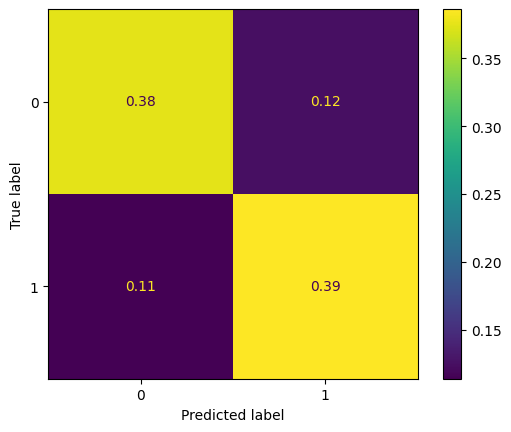

In [529]:
import sklearn

cm = sklearn.metrics.confusion_matrix(y_test, predictions, normalize='all')
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

# Optuna

In [ ]:
def objective(trial):
    # Suggest hyperparameters
    batch_size = trial.suggest_int('batch_size', 64, 256)
    lr = trial.suggest_float('lr', 1e-4, 1e-3, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-5, 1e-3, log=True)

    # DataLoader
    train_dloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, pin_memory=True)
    val_dloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, pin_memory=True)
    test_dloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    # Model
    resnet_params = {
        'layers': [2, 2, 2, 2],
        "in_channel":12, 
        "out_channel":1, 
        "zero_init_residual":True
    }
    model = ResNet(Bottleneck, **resnet_params)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)

    # Define loss function, optimizer, and scheduler
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)

    # Training loop
    epochs = 20
    best_val_loss = float('inf')
    patience_counter = 0
    patience = 7
    
    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        n_elements = 0
        for X, y, age, sex in tqdm(train_dloader, desc=f"Epoch {epoch+1}/{epochs}"):
            X, y = X.to(device), y.to(device)
            age, sex = age.to(device), sex.to(device)
            # Combine age and sex into a single demographic tensor
            demographic = torch.stack((age, sex), dim=1)
            
            optimizer.zero_grad()
            outputs = model(X, demographic)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            n_elements += len(X)
        
        train_loss /= n_elements
        
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X, y, age, sex in val_dloader:
                X, y = X.to(device), y.to(device)
                age, sex = age.to(device), sex.to(device)
                demographic = torch.stack((age, sex), dim=1)
                outputs = model(X, demographic)
                loss = criterion(outputs, y)
                val_loss += loss.item()
        
        val_loss /= len(val_dloader)
        scheduler.step(val_loss)
        
        print(f"Epoch {epoch+1}/{epochs}\tTrain Loss: {train_loss:.4f}\tVal Loss: {val_loss:.4f}\tL.rate: {optimizer.param_groups[0]['lr']:.4f}")
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), "best_model.pth")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break

    # Load back the best model found
    model = ResNet(Bottleneck, **resnet_params)
    model.to(device)
    model.load_state_dict(torch.load("best_model.pth", weights_only=True))

    # Test the model
    model.eval()
    
    # Initialize a list to store predictions
    predictions = []
    
    # Disable gradient calculation for inference
    with torch.no_grad():
        for X, _, age, sex in tqdm(test_dloader, desc="Predicting"):
            X = X.to(device)
            age, sex = age.to(device), sex.to(device)
            demographic = torch.stack((age, sex), dim=1)
            outputs = model(X, demographic)  # Raw logits
            probs = torch.sigmoid(outputs)  # Convert logits to probabilities
            y_pred = (probs >= 0.5).long()  # Convert probabilities to {0,1}
            predictions.extend(y_pred.cpu().numpy())  # Convert to NumPy array
    
    # Convert predictions to a NumPy array
    predictions = np.array(predictions)

    # Metrics
    rocauc = roc_auc_score(y_test, predictions)

    return rocauc

In [ ]:
# Create an Optuna study
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=10)

In [ ]:
# Display the best hyperparameters and ROC AUC score
print("Best hyperparameters:", study.best_params)
print("Best ROC-AUC:", study.best_value)